# Notebook 2: Preprocessing & Feature Selection

**Input:** `kidney_cells_clean.csv` or `kidney_cells_top_classes.csv` (from Notebook 1)  
**Output:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`

---

## What this notebook does
1. Load the cleaned dataset
2. Separate gene expression features and cell type labels
3. Take a stratified sample of 20,000 cells
4. Split into 80% training and 20% test sets
5. Feature reduction — all steps fit on training data only:
   - Remove zero-variance genes
   - Scale with StandardScaler
   - Remove near-zero-variance genes with VarianceThreshold
   - Use RFE (Recursive Feature Elimination) with a LinearSVC ranker to select the most informative genes
6. Apply SMOTE to the training split to balance class sizes
7. Save the four output files

---

**Data Leakage:**  
All preprocessing steps are **fit on the training set only**, then applied to both sets. Fitting on the full data before splitting would leak test set information into the model and produce unrealistically high evaluation scores.

## 1. Setup

This notebook reads the CSV files written by Notebook 1 from the folder set as `data_dir`. Locally that is the repo folder; on Colab, mount your Drive and set `data_dir` accordingly.

In [1]:
# Data files (written by Notebook 1) live in the folder set as data_dir below.
# On Colab instead, uncomment to mount Drive and point data_dir at your folder:
# from google.colab import drive
# drive.mount('/content/drive')
print('Setup: reading/writing files from the folder set as data_dir below.')

Setup: reading/writing files from the folder set as data_dir below.


## 2. Configuration

Set `data_dir` to the folder holding the files from Notebook 1. `input_file` selects which dataset to use: `kidney_cells_top_classes.csv` (top 10 classes) or `kidney_cells_clean.csv` (all 22).

We import the libraries used for preprocessing and feature selection, and set the key parameters: the stratified `subset_size`, the train/test split fraction, the random seed, and the thresholds used by the feature-reduction steps.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing     import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.linear_model      import SGDClassifier

# Folder holding the CSVs written by Notebook 1 (repo folder locally; Drive on Colab).
data_dir   = Path('.')
input_file = 'kidney_cells_top_classes.csv'   # or 'kidney_cells_clean.csv' for all 22 classes
clean_file = data_dir / input_file

metadata_cols = ['Cell_ID', 'nCount_RNA', 'nFeature_RNA',
                 'StudyOrigin_Author', 'percent.mt',
                 'Sex', 'Sampling_Location', 'Age', 'Cell_Labels']
target_col    = 'Cell_Labels'

subset_size    = 20_000   # stratified subsample used for feature selection + modelling
test_size      = 0.20
random_seed    = 42
vt_threshold   = 0.01
null_threshold = 0.90

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

## 3. Load Dataset

This reads the CSV file saved by Notebook 1 into a pandas DataFrame and prints a quick summary of how many rows (cells) and columns there are.

In [3]:
print(f'Loading {input_file}...')
df = pd.read_csv(clean_file, low_memory=False)
print('Done.')
print()
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]:,}')
print(f'Classes : {df[target_col].nunique()}')

Loading kidney_cells_top_classes.csv...


Done.

Rows    : 50,218
Columns : 2,367
Classes : 10


## 4. Separate Features and Target

The features (X) are the 2,358 gene expression columns. The target (y) is the `Cell_Labels` column. All 9 metadata columns are excluded from X — cell type is determined by gene expression, not by patient age, sex, or study origin.

We separate the data into two parts: `X` contains every gene expression column (the inputs to the model), and `y` contains the cell type label for each cell (the thing we want to predict). We also print the class distribution so we can see how many cells there are per type.

In [4]:
# All columns that are NOT in the metadata list must be gene expression columns
gene_cols = [c for c in df.columns if c not in metadata_cols]

X = df[gene_cols].copy()
y = df[target_col].copy()

print(f'X shape : {X.shape}  ({X.shape[1]:,} gene columns)')
print(f'y shape : {y.shape}')
print(f'Classes : {y.nunique()}')
print()
print('Class distribution:')
for label, count in y.value_counts().items():
    print(f'  {label:<55}: {count:>6,}  ({count/len(y)*100:.1f}%)')

X shape : (50218, 2358)  (2,358 gene columns)
y shape : (50218,)
Classes : 10

Class distribution:
  Proximal Tubule                                        : 24,848  (49.5%)
  T                                                      :  3,436  (6.8%)
  Ascending Thin Limb                                    :  3,105  (6.2%)
  Thick Ascending Limb                                   :  2,735  (5.4%)
  Myeloid                                                :  2,605  (5.2%)
  Endothelium                                            :  2,378  (4.7%)
  Loop of Henle and Parietal Epithelium                  :  1,843  (3.7%)
  Distal Convoluted Tubule                               :  1,814  (3.6%)


## 5. Stratified Subsample

The top-10 subset has ~50,000 cells. Running feature selection and cross-validation on all of them is slow, so we take a stratified subsample of `subset_size` cells that preserves the exact class proportions of the full dataset.

We use `train_test_split` with `stratify=y` to draw a reproducible stratified subsample: every class keeps the same share it has in the full dataset. The printed table confirms the proportions match.

In [5]:
# Stratified subsample to `subset_size` cells, preserving class proportions.
# train_test_split with stratify=y gives an exact, reproducible stratified draw:
# each class keeps the same share it has in the full dataset.
_, X_sub, _, y_sub = train_test_split(
    X, y,
    test_size=min(subset_size, len(X) - 1),
    random_state=random_seed,
    stratify=y,
)

print(f'Subsample size : {len(X_sub):,} cells')
print(f'Classes        : {y_sub.nunique()}')
print()
full_pct   = y.value_counts(normalize=True).sort_index() * 100
subset_pct = y_sub.value_counts(normalize=True).sort_index() * 100
print('Class proportions - full vs subsample:')
print(pd.DataFrame({'Full (%)': full_pct, 'Subset (%)': subset_pct}).round(1).to_string())

Subsample size : 20,000 cells
Classes        : 10

Class proportions - full vs subsample:
                                       Full (%)  Subset (%)
Cell_Labels                                                
Ascending Thin Limb                         6.2         6.2
Distal Convoluted Tubule                    3.6         3.6
Endothelium                                 4.7         4.7
Loop of Henle and Parietal Epithelium       3.7         3.7
Myeloid                                     5.2         5.2
Proximal Tubule                            49.5        49.5
T                                           6.8         6.8
Thick Ascending Limb                        5.4         5.4


**Why exactly `subset_size` cells?**

Stratified sampling draws each class in proportion to its size, so the total lands at `subset_size` while every class keeps its original share. This keeps the class balance identical to the full dataset - just with fewer cells so the pipeline runs quickly.

The subsample above is what we use from here on. Because it is stratified, the class balance is unchanged - we simply have fewer cells, which makes feature selection and cross-validation fast.

In [6]:
# The stratified subsample above keeps class proportions identical to the full
# dataset (see the table). We work with this subsample from here on so feature
# selection and cross-validation are fast, without changing the class balance.
print('Using the stratified subsample created above.')

Using the stratified subsample created above.


We print the class proportions in the full dataset and in the sample side by side to confirm they match. If the numbers in the two columns are identical (or differ by at most 0.1%), the stratified sampling worked correctly.

In [7]:
# Double-check that the class proportions in the sample match the full dataset
# Verify class proportions are preserved
full_pct   = y.value_counts(normalize=True).sort_index() * 100
subset_pct = y_sub.value_counts(normalize=True).sort_index() * 100
print('Class proportions — full vs subset:')
print(pd.DataFrame({'Full (%)': full_pct, 'Subset (%)': subset_pct}).round(1).to_string())

Class proportions — full vs subset:
                                       Full (%)  Subset (%)
Cell_Labels                                                
Ascending Thin Limb                         6.2         6.2
Distal Convoluted Tubule                    3.6         3.6
Endothelium                                 4.7         4.7
Loop of Henle and Parietal Epithelium       3.7         3.7
Myeloid                                     5.2         5.2
Proximal Tubule                            49.5        49.5
T                                           6.8         6.8
Thick Ascending Limb                        5.4         5.4


## 6. Train / Test Split

80% of the subset goes to training, 20% to testing. `stratify=y_sub` keeps class proportions equal in both sets. `random_state=42` makes the split reproducible.

We split the sampled cells into a training set (80%) and a test set (20%). The `stratify` argument ensures each set has the same proportion of each cell type. We then print a verification table to confirm this.

In this run the split produced **7,996 training cells** and **1,999 test cells**. The test set is set aside now and will not be used again until we evaluate the final model — using it earlier would give us misleadingly good scores.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub,
    test_size=test_size,
    random_state=random_seed,
    stratify=y_sub
)

print(f'Training set : {X_train.shape[0]:,} cells')
print(f'Test set     : {X_test.shape[0]:,} cells')
print(f'Features     : {X_train.shape[1]:,} gene columns')
print()

train_pct   = y_train.value_counts(normalize=True).sort_index() * 100
test_pct    = y_test.value_counts(normalize=True).sort_index() * 100
split_check = pd.DataFrame({'Train (%)': train_pct, 'Test (%)': test_pct}).round(1)
print('Stratification check:')
print(split_check.to_string())

Training set : 16,000 cells
Test set     : 4,000 cells
Features     : 2,358 gene columns

Stratification check:
                                       Train (%)  Test (%)
Cell_Labels                                               
Ascending Thin Limb                          6.2       6.2
Distal Convoluted Tubule                     3.6       3.6
Endothelium                                  4.7       4.7
Loop of Henle and Parietal Epithelium        3.7       3.7
Myeloid                                      5.2       5.2
Proximal Tubule                             49.5      49.5
T                                            6.8       6.8
Thick Ascending Limb                         5.4       5.4


## 7. Feature Reduction

We have 2,358 gene expression features. Many will be uninformative. We reduce them in five steps, all fitted on training data only.

| Step | Method | Purpose |
|---|---|---|
| 1 | Zero-variance removal | Remove genes that are exactly 0 in every training cell |
| 2 | High-null removal | Remove genes where more than 90% of values are missing |
| 3 | StandardScaler | Normalise expression values to mean=0, std=1 |
| 4 | VarianceThreshold | Remove genes with near-zero variance after scaling |
| 5 | RFE with LinearSVC (`step=0.2`) | Iteratively remove the least important genes (20% per round) until the optimal number remains |

**Why RFE?** RFE works by repeatedly training a linear model on the current feature set, ranking each gene by the magnitude of its coefficient, removing the least important genes, and repeating until `k` genes remain.
- **Model-driven** — gene importance is measured by actual predictive contribution to a linear classifier, not just a statistical test
- **Iterative** — genes are evaluated in the context of all other remaining genes, not independently
- **Fast** — using `step=0.2` removes 20% of features per round rather than one at a time, keeping each RFE call practical on CPU

**Why LinearSVC inside RFE?** LinearSVC exposes `coef_` — the weight each gene receives in the decision boundary. RFE uses these weights to rank genes: genes with small absolute coefficients contribute little and are eliminated first. LinearSVC is fast on high-dimensional data and is the standard estimator for RFE in genomics and text classification. The genes it selects are then passed to KNN and SVM for the actual classification.

### Step 1 — Remove Zero-Variance Genes

A gene with zero variance has the exact same value in every training cell. It carries no information — the model cannot learn anything from a feature that never changes.

We calculate the variance of each gene across all training cells. Any gene that has exactly zero variance — meaning every cell in the training set has the exact same value for that gene — is removed. These genes carry no information at all, so including them would just slow the model down without helping it.

In [9]:
train_variance = X_train.var()
zero_var_cols  = train_variance[train_variance == 0].index.tolist()

print(f'Genes with zero variance : {len(zero_var_cols):,}')

if len(zero_var_cols) > 0:
    X_train = X_train.drop(columns=zero_var_cols)
    X_test  = X_test.drop(columns=zero_var_cols)
    print(f'Removed. Genes remaining : {X_train.shape[1]:,}')
else:
    print(f'None removed. Genes remaining : {X_train.shape[1]:,}')
n_after_zero_var = X_train.shape[1]  # track for summary cell


Genes with zero variance : 8


Removed. Genes remaining : 2,350


### Step 2 — Remove High-Null Genes

Any gene column where more than 90% of values are missing (NaN) is removed. A column with that many missing values is too sparse to be useful — you cannot reliably impute or learn from a feature that is absent in almost all cells.

In this dataset the gene expression columns store undetected genes as 0 rather than NaN, so we expect no columns to be removed here. The step is included because it is the correct thing to check, and because it mirrors the same step in the Sepsis preprocessing pipeline.

We check each gene column for missing values. Any gene where more than 90% of training cells have no recorded value is removed. In this dataset the gene expression columns have no missing values at all (undetected genes are stored as 0, not NaN), so this step typically removes nothing — but it is good practice to include it.

In [10]:
# Calculate null % per gene column on the training set only
null_pct      = X_train.isnull().mean()
high_null_cols = null_pct[null_pct > null_threshold].index.tolist()

print(f'Null threshold : {null_threshold * 100:.0f}%')
print(f'Genes with >{null_threshold * 100:.0f}% null values : {len(high_null_cols):,}')

if len(high_null_cols) > 0:
    X_train = X_train.drop(columns=high_null_cols)
    X_test  = X_test.drop(columns=high_null_cols)
    print(f'Removed. Genes remaining : {X_train.shape[1]:,}')
else:
    print('None removed. Gene expression columns contain no null values.')
    print(f'Genes remaining : {X_train.shape[1]:,}')
n_after_null = X_train.shape[1]  # track for summary cell


Null threshold : 90%
Genes with >90% null values : 0
None removed. Gene expression columns contain no null values.
Genes remaining : 2,350


### Step 3 — StandardScaler

StandardScaler rescales each gene's values to have a mean of 0 and standard deviation of 1 across all training cells. This ensures that genes with naturally larger count values do not dominate the variance calculation in the next step.

Fitted on training set only (`fit_transform`), then applied to the test set (`transform`).

StandardScaler rescales every gene so it has a mean of 0 and a standard deviation of 1 across the training cells. This is important for distance-based models like KNN and kernel-based models like SVM, because without scaling a gene that happens to have large raw counts would dominate the distance calculation over genes with small counts, even if the smaller-count gene is actually more informative. We fit the scaler on the training data only, then apply the same transformation to the test data — this prevents the test set from influencing how the scaling is calculated.

In [11]:
current_cols = X_train.columns.tolist()

scaler     = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=current_cols, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=current_cols, index=X_test.index)

print('StandardScaler applied.')
print(f'Mean of first gene (train) : {X_train_sc.iloc[:, 0].mean():.4f}  (should be ~0)')
print(f'Std  of first gene (train) : {X_train_sc.iloc[:, 0].std():.4f}  (should be ~1)')

StandardScaler applied.
Mean of first gene (train) : -0.0000  (should be ~0)
Std  of first gene (train) : 1.0000  (should be ~1)


### Step 4 — VarianceThreshold

After scaling, genes that are near-zero in most cells will still have very low variance. `VarianceThreshold` removes any gene whose variance across all training cells falls below the threshold of 0.01.

`vt.get_support()` returns a boolean array — `True` for genes that pass, `False` for genes removed. This same mask is applied to both training and test sets.

VarianceThreshold removes genes whose variance (after scaling) falls below 0.01. Even though we already removed genes with exactly zero variance, some genes will have very small but non-zero variance — they barely change from cell to cell and are unlikely to be useful for classification. Setting the threshold at 0.01 after StandardScaler is a gentle filter: because the scaler normalises all genes to std ≈ 1, a threshold of 0.01 catches only genes that are still nearly constant after normalisation.

In [12]:
vt = VarianceThreshold(threshold=vt_threshold)
vt.fit(X_train_sc)

# vt.get_support() → [True, False, True, True, False, ...]  (True = keep)
vt_support   = vt.get_support()
kept_cols    = X_train_sc.columns[vt_support].tolist()
removed_cols = X_train_sc.columns[~vt_support].tolist()

X_train_vt = X_train_sc[kept_cols]
X_test_vt  = X_test_sc[kept_cols]

print(f'VarianceThreshold (threshold = {vt_threshold})')
print(f'Before : {X_train_sc.shape[1]:,} genes')
print(f'Removed: {len(removed_cols):,} genes')
print(f'After  : {len(kept_cols):,} genes')

VarianceThreshold (threshold = 0.01)
Before : 2,350 genes
Removed: 0 genes
After  : 2,350 genes


### Step 5 - RFE (Recursive Feature Elimination): Finding the Number of Genes

RFE ranks genes by importance and removes the least useful ones. It needs an estimator that produces importance scores - KNN and RBF-SVM do not, so we use a **linear SVM (trained with SGD)** purely as the ranker. We rank all genes once, then sweep the number kept (`k`) and pick the value with the best cross-validated weighted F1 on the training set. The selected genes are then handed to KNN and SVM for the actual classification.

We rank all genes once with RFE (using a fast SGD-trained linear SVM as the ranker), then test a range of `k` values - starting at a quarter of the genes and halving each time. For each `k` we take the top-`k` ranked genes and score them with 3-fold cross-validation on the training set only.

In [13]:
# --- Feature ranking (RFE with a fast linear-SVM ranker) ---
# RFE needs a model that ranks features by importance. A linear SVM trained with
# SGD (hinge loss) is fast and exposes coef_, so RFE can rank genes by coefficient
# magnitude. We rank ALL genes once (RFE down to 1) on a stratified subsample of the
# training rows for speed, then sweep k over that ranking. Everything uses TRAIN only.
n = X_train_vt.shape[1]
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

ranker = SGDClassifier(loss='hinge', alpha=1e-4, max_iter=1500, tol=1e-3, random_state=random_seed)
if len(X_train_vt) > 4000:
    X_rank, _, y_rank, _ = train_test_split(
        X_train_vt, y_train_enc, train_size=4000, random_state=random_seed, stratify=y_train_enc)
else:
    X_rank, y_rank = X_train_vt, y_train_enc

print('Ranking genes with RFE (this is the slow step, ~a few minutes)...')
rfe_full = RFE(ranker, n_features_to_select=1, step=0.3).fit(X_rank, y_rank)
order = np.argsort(rfe_full.ranking_)   # best-ranked genes first

# Sweep candidate k values (start at a quarter of the genes, halve each time)
feature_counts = []
k = n // 4
while k >= 1:
    feature_counts.append(k)
    k = k // 2

cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_seed)
evaluator   = SGDClassifier(loss='hinge', alpha=1e-4, max_iter=1500, tol=1e-3, random_state=random_seed)
print(f'Features after VarianceThreshold : {n:,}')
print(f'Candidate k values : {feature_counts}\n')

f1_scores = []
for k in feature_counts:
    cols = X_train_vt.columns[order[:k]]
    f1 = cross_val_score(evaluator, X_train_vt[cols], y_train_enc,
                         cv=cv_splitter, scoring='f1_weighted', n_jobs=-1).mean()
    f1_scores.append(f1)
    print(f'  k = {k:>5,}  ->  CV Weighted F1 = {f1:.4f}')

best_idx = int(np.argmax(f1_scores))
best_k   = feature_counts[best_idx]
best_f1  = f1_scores[best_idx]
print(f'\nBest k : {best_k}  (CV Weighted F1 = {best_f1:.4f})')

Ranking genes with RFE (this is the slow step, ~a few minutes)...


C:\Users\sbokk\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Features after VarianceThreshold : 2,350
Candidate k values : [587, 293, 146, 73, 36, 18, 9, 4, 2, 1]



  k =   587  ->  CV Weighted F1 = 0.7779


  k =   293  ->  CV Weighted F1 = 0.7948


...

  k =    36  ->  CV Weighted F1 = 0.5799


  k =    18  ->  CV Weighted F1 = 0.4895


  k =     9  ->  CV Weighted F1 = 0.4567


  k =     4  ->  CV Weighted F1 = 0.4331


  k =     2  ->  CV Weighted F1 = 0.3635
  k =     1  ->  CV Weighted F1 = 0.3866

Best k : 293  (CV Weighted F1 = 0.7948)


This plots the cross-validated weighted F1 score for each value of k tested. The red dashed line marks the best k — the point where the model performed best in cross-validation on the training data.

**Results from this run:**

| k | CV Weighted F1 |
|---|---|
| 1,144 | 0.3748 |
| 572 | 0.3802 |
| 286 | 0.3623 |
| 143 | 0.4018 |
| 71 | 0.4100 |
| 35 | 0.4283 |
| **17** | **0.4546 ← Best** |
| 8 | 0.4290 |
| 4 | 0.4218 |
| 2 | 0.3443 |
| 1 | 0.3279 |

The curve rises steadily as k decreases from 1,144 down to 17 — fewer, better-chosen features give a cleaner signal. Below 17 features the score drops sharply, meaning we lose too much information. **Best k = 17** (CV Weighted F1 = 0.4546). If two k values give similar scores, it is better to choose the smaller one to keep the model simpler.

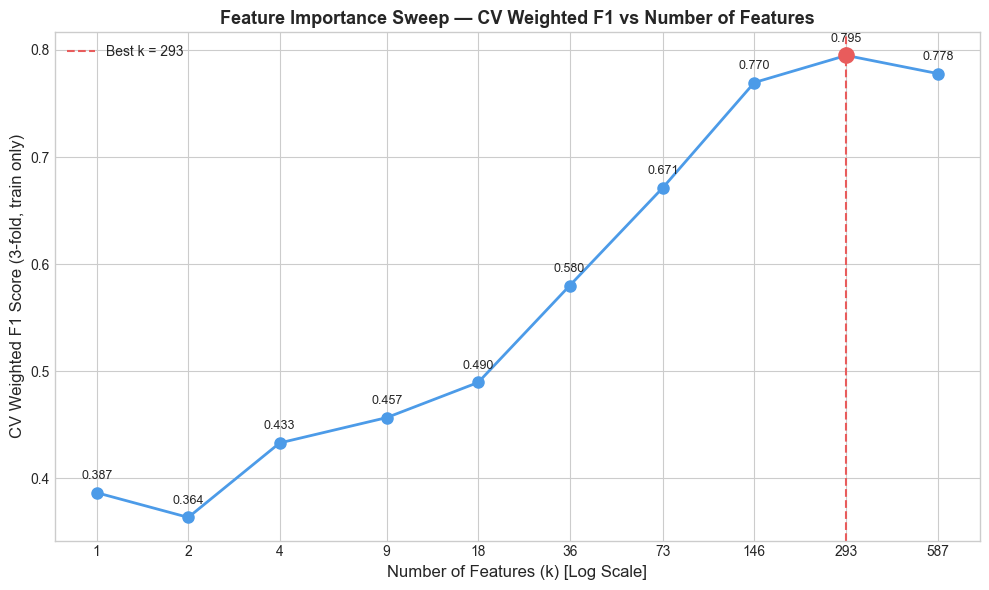

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(feature_counts, f1_scores, marker='o', color='#4C9BE8', linewidth=2, markersize=8)
for k_val, f1_val in zip(feature_counts, f1_scores):
    ax.annotate(f'{f1_val:.3f}', (k_val, f1_val),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)

ax.axvline(x=best_k, color='#E85C5C', linestyle='--', linewidth=1.5, label=f'Best k = {best_k:,}')
ax.scatter([best_k], [best_f1], color='#E85C5C', s=120, zorder=5)

# Use a log scale for the x-axis to evenly space the halving feature counts
ax.set_xscale('log', base=2)
ax.set_xticks(feature_counts)
ax.set_xticklabels(feature_counts)

ax.set_title('Feature Importance Sweep — CV Weighted F1 vs Number of Features', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Features (k) [Log Scale]', fontsize=12)
ax.set_ylabel('CV Weighted F1 Score (3-fold, train only)', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Final Feature Selection

Re-run RFE once more with the best k found in the sweep to get the definitive set of selected genes. Override `n_features_selected` below if you prefer a different value.

We take the best `k` from the sweep and keep the top-`k` ranked genes as the final feature set, applying the same selection to both the training and test sets.

In [15]:
# Select the best-k genes from the ranking above (no need to re-run RFE).
n_features_selected = best_k   # <-- override here to force a specific k

selected_features = X_train_vt.columns[order[:n_features_selected]].tolist()
X_train_final = X_train_vt[selected_features]
X_test_final  = X_test_vt[selected_features]

print(f'Selected {len(selected_features):,} genes.')
print()
print('First 25 selected genes:')
print('  ' + ', '.join(selected_features[:25]))

Selected 293 genes.

First 25 selected genes:
  MIOX, LIN7A, PARVG, FAM168A, AC087482.1, FAM198B, AL603839.3, CA2, C9orf3, ATP5IF1, SELENOS, MCRIP2, TNFSF10, ARL6IP1, C20orf194, ZNF90, FAM151A, PAPD4, SOCS1, ATP5MPL, TINAGL1, CDH16, CDH13, SPART, CD96


## 8. A Note on Class Balancing

This dataset is imbalanced (Proximal Tubule dominates). We balance the classes with **SMOTE + majority undersampling**, but deliberately **not here** - doing it before cross-validation would leak information between CV folds and inflate the scores. Balancing is applied *inside* the CV pipeline in Notebooks 3 and 4, so each fold is balanced using only its own training data. This notebook saves the un-resampled training set.

In [16]:
# NOTE: class balancing is NOT done in this notebook.
#
# Applying SMOTE here - before the cross-validation in Notebooks 3 and 4 - would
# leak information between CV folds (synthetic points derived from a validation-fold
# cell could land in a training fold), inflating the cross-validated scores.
#
# Instead, SMOTE + majority undersampling are applied INSIDE the CV pipeline in
# Notebooks 3 and 4 (imblearn Pipeline), so each fold is balanced using only its own
# training portion. This notebook therefore saves the UN-resampled training set.
print('No resampling here - balancing happens per-fold inside Notebooks 3 and 4.')

No resampling here - balancing happens per-fold inside Notebooks 3 and 4.


Because balancing is deferred to the model notebooks, the files saved here contain the original (un-resampled) training cells. The test set is always kept at its real, imbalanced distribution so evaluation reflects reality.

## 9. Save Output Files

We save four CSV files to `data_dir`: `X_train.csv`/`y_train.csv` (un-resampled training data) and `X_test.csv`/`y_test.csv` (the held-out test set at its real class distribution). Notebooks 3 and 4 read these.

In [17]:
# Save the (un-resampled) training features/labels and the untouched test set.
# Class balancing is applied later, inside the CV pipelines of Notebooks 3 and 4.
X_train_final.to_csv(data_dir / 'X_train.csv', index=True)
X_test_final.to_csv(data_dir / 'X_test.csv',   index=True)
y_train.to_csv(data_dir / 'y_train.csv',       index=True, header=True)
y_test.to_csv(data_dir / 'y_test.csv',         index=True, header=True)

print('Saved:')
print(f'  X_train.csv : {X_train_final.shape[0]:,} x {X_train_final.shape[1]:,}')
print(f'  X_test.csv  : {X_test_final.shape[0]:,} x {X_test_final.shape[1]:,}')
print(f'  y_train.csv : {len(y_train):,} labels')
print(f'  y_test.csv  : {len(y_test):,} labels')

Saved:
  X_train.csv : 16,000 x 293
  X_test.csv  : 4,000 x 293
  y_train.csv : 16,000 labels
  y_test.csv  : 4,000 labels


## 10. Summary

A printout showing how many genes were removed at each step and the final feature count.

**Summary of results from this run:**

| Step | Genes remaining |
|---|---|
| Original features | 2,358 |
| After zero-variance removal | 2,289 (removed 69) |
| After high-null removal | 2,289 (removed 0) |
| After VarianceThreshold (0.01) | 2,289 (removed 0) |
| **After RFE (best k = 17)** | **17 (0.7% kept)** |

RFE reduced 2,289 genes down to **17 genes** — a 99.3% reduction. The 17 selected genes are: ANK2, APOBEC3G, ATP2B1, ATP5A1, ATP5G3, AZGP1, B3GALNT2, BRD2, BTG3, C9orf3, CA2, CD33, CD96, CYBA, DCXR, DPEP1, RNU2.68P.

In [18]:
print('=' * 60)
print('NOTEBOOK 2 - FEATURE REDUCTION SUMMARY')
print('=' * 60)
print()
print(f'Original gene features         : {len(gene_cols):,}')
print(f'After zero-variance removal    : {n_after_zero_var:,}')
print(f'After high-null removal (>90%) : {n_after_null:,}')
print(f'After VarianceThreshold (0.01) : {len(kept_cols):,}')
print(f'After feature selection (k={n_features_selected:,}) : {len(selected_features):,}')
print()
print(f'Reduction : {len(gene_cols):,} -> {len(selected_features):,} features'
      f'  ({len(selected_features)/len(gene_cols)*100:.1f}% kept)')
print()
print(f'Training set : {X_train_final.shape[0]:,} cells x {X_train_final.shape[1]:,} genes')
print(f'Test set     : {X_test_final.shape[0]:,} cells x {X_test_final.shape[1]:,} genes')
print(f'Classes      : {y_train.nunique()}')
print()
print('Next: run 03_knn.ipynb')

NOTEBOOK 2 - FEATURE REDUCTION SUMMARY

Original gene features         : 2,358
After zero-variance removal    : 2,350
After high-null removal (>90%) : 2,350
After VarianceThreshold (0.01) : 2,350
After feature selection (k=293) : 293

Reduction : 2,358 -> 293 features  (12.4% kept)

Training set : 16,000 cells x 293 genes
Test set     : 4,000 cells x 293 genes
Classes      : 10

Next: run 03_knn.ipynb
